# Transformer Ensemble for Natural Language Inference

**COMP34812 NLU Coursework - Category A (Transformer Architecture)**

This notebook implements a blending ensemble of transformer models (DeBERTa, RoBERTa, ELECTRA) for binary NLI classification. It includes:
- Hyperparameter optimization with Optuna
- LoRA and selective layer freezing for parameter-efficient fine-tuning
- Adversarial training with Fast Gradient Method (FGM)
- XGBoost meta-learner for ensemble predictions

## 1. Setup & Imports

Import all required libraries: PyTorch for deep learning, Hugging Face transformers for pre-trained models, PEFT for LoRA, scikit-learn for metrics, Optuna for hyperparameter search, and XGBoost for the meta-learner.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Hugging Face transformers and PEFT
from transformers import get_linear_schedule_with_warmup
from transformers import AutoModelForSequenceClassification, AutoConfig
from transformers import AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType

# Utilities/ Misc
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import joblib
import os
import optuna
import gc
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Save current environment for reproducibility
%pip freeze > requirements_314.txt

C:\Users\Julius\git\NLU\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: you may need to restart the kernel to use updated packages.


## 2. Dataset & Evaluation Utilities

Define the PyTorch Dataset class for NLI data and an evaluation helper function. The dataset:
- Accepts a pandas DataFrame directly (useful for K-Fold cross-validation)
- Tokenizes premise-hypothesis pairs using the model's tokenizer
- Returns input tensors ready for the transformer model

In [18]:
class NLIDataset_DF(Dataset):
    """
    PyTorch Dataset for Natural Language Inference.
    Accepts a Pandas DataFrame and conditionally handles blind test sets missing the 'label' column.
    """
    def __init__(self, dataframe, tokenizer_name, max_length=128):
        # Reset index to ensure consistent indexing after DataFrame slicing
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Extract premise and hypothesis text
        premise = str(self.data.loc[idx, 'premise'])
        hypothesis = str(self.data.loc[idx, 'hypothesis'])

        # Tokenize the premise-hypothesis pair
        # The tokenizer natively handles architecture-specific separator formatting
        encoding = self.tokenizer(
            premise,
            hypothesis,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

        # Conditionally handle the label column for blind inference sets
        if 'label' in self.data.columns:
            label = int(self.data.loc[idx, 'label'])
            item['labels'] = torch.tensor(label, dtype=torch.long)
        else:
            # Assign a dummy label (-1) to maintain PyTorch DataLoader collation structure
            item['labels'] = torch.tensor(-1, dtype=torch.long)

        return item


def evaluate_model(model, dataloader, device):
    """
    Evaluates model performance on a validation set.
    Returns the macro F1 score and average loss.
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            loss, logits = model(input_ids, attention_mask, labels)
            total_loss += loss.item()

            # Convert logits to predicted class
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    # Macro F1 weights both classes equally regardless of potential class imbalance
    f1 = f1_score(all_labels, all_preds, average='macro')

    return f1, avg_loss

## 3. Blending Ensemble Class

The `NLIBlendingEnsemble` orchestrates the entire ensemble pipeline:

1. **Phase 1 (`fit_base_models`)**: Train each transformer model independently on the training set
2. **Phase 2 (`fit_meta_learner`)**: Extract probability predictions from all models on the dev set, then train an XGBoost meta-learner to combine them
3. **Phase 3 (`predict`)**: Generate final predictions on test data by feeding base model probabilities to the meta-learner

In [19]:
class NLIBlendingEnsemble:
    """
    Orchestrator class for Blending Ensemble.
    Trains multiple base transformer models, then uses a meta-learner
    to combine their predictions for improved accuracy.
    """
    def __init__(self, model_configs, model_save_dir='./saved_models'):
        self.model_configs = model_configs
        self.num_models = len(model_configs)
        self.model_save_dir = model_save_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.num_labels = 2

        os.makedirs(self.model_save_dir, exist_ok=True)

        # XGBoost meta-learner
        self.meta_learner = XGBClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1          # Parallelize across all CPU cores
        )
        self.meta_learner_path = os.path.join(self.model_save_dir, 'meta_learner_xgb.json')

    def _get_predictions(self, model, dataloader):
        """Extract softmax probabilities from a base model."""
        model.eval()
        all_probs = []
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                _, logits = model(input_ids, attention_mask, labels=None)
                probs = F.softmax(logits, dim=1)
                all_probs.append(probs.cpu().numpy())
        return np.vstack(all_probs)

    def fit_base_models(self, train_csv_path, dev_csv_path):
        """Train all base models on the training set."""
        print(f"=== Phase 1: Training Base Models ===")
        train_df = pd.read_csv(train_csv_path).dropna().reset_index(drop=True)
        dev_df = pd.read_csv(dev_csv_path).dropna().reset_index(drop=True)

        for m_idx, config in enumerate(self.model_configs):
            model_name_clean = config['model_name'].replace("/", "_")
            print(f"\n--- TRAINING MODEL {m_idx + 1}/{self.num_models}: {config['model_name']} ---")

            # Create datasets with model-specific tokenizer
            train_dataset = NLIDataset_DF(train_df, config['model_name'])
            val_dataset = NLIDataset_DF(dev_df, config['model_name'])

            bs = config.get('batch_size', 8)
            train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=0)
            val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=0)

            model = NLITransformerWrapper(config)
            save_path = os.path.join(self.model_save_dir, f"{model_name_clean}_best.pt")

            # Train and save best checkpoint
            train_nli_model(model, train_loader, val_loader, config, fold_name=save_path)

    def fit_meta_learner(self, dev_csv_path):
        """Train meta-learner on dev set predictions from all base models."""
        print(f"\n=== Phase 2: Training Meta-Learner on Validation Set ===")
        dev_df = pd.read_csv(dev_csv_path).dropna().reset_index(drop=True)

        # Feature matrix: (num_samples) x (num_models * 2 probabilities)
        dev_meta_features = np.zeros((len(dev_df), self.num_models * self.num_labels))

        for m_idx, config in enumerate(self.model_configs):
            model_name_clean = config['model_name'].replace("/", "_")
            print(f"Extracting dev features from {config['model_name']}...")

            val_dataset = NLIDataset_DF(dev_df, config['model_name'])
            val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

            # Load trained base model
            model = NLITransformerWrapper(config)
            save_path = os.path.join(self.model_save_dir, f"{model_name_clean}_best.pt")
            model.load_state_dict(torch.load(save_path))
            model.to(self.device)

            # Fill in the feature columns for this model
            start_col = m_idx * self.num_labels
            end_col = start_col + self.num_labels
            dev_meta_features[:, start_col:end_col] = self._get_predictions(model, val_loader)

        # Train XGBoost on the stacked probabilities
        true_labels = dev_df['label'].values
        self.meta_learner.fit(dev_meta_features, true_labels)

        meta_preds = self.meta_learner.predict(dev_meta_features)
        meta_f1 = f1_score(true_labels, meta_preds, average='macro')
        print(f"Meta-Learner Blending F1 Score: {meta_f1:.4f}")

        self.meta_learner.save_model(self.meta_learner_path)

    def predict(self, test_csv_path, output_filename):
        """Generate final predictions on a test set"""
        print(f"\n=== Phase 3: Ensemble Inference ===")
        test_df = pd.read_csv(test_csv_path).dropna().reset_index(drop=True)
        test_meta_features = np.zeros((len(test_df), self.num_models * self.num_labels))

        # Extract predictions from each base model
        for m_idx, config in enumerate(self.model_configs):
            model_name_clean = config['model_name'].replace("/", "_")
            print(f"Extracting test features from {config['model_name']}...")

            test_dataset = NLIDataset_DF(test_df, config['model_name'])
            test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

            model = NLITransformerWrapper(config)
            save_path = os.path.join(self.model_save_dir, f"{model_name_clean}_best.pt")
            model.load_state_dict(torch.load(save_path))
            model.to(self.device)

            start_col = m_idx * self.num_labels
            end_col = start_col + self.num_labels
            test_meta_features[:, start_col:end_col] = self._get_predictions(model, test_loader)

        # Load meta-learner and generate final predictions
        print("Feeding combined features to Meta-Learner...")
        self.meta_learner = XGBClassifier()
        self.meta_learner.load_model(self.meta_learner_path)

        final_preds = self.meta_learner.predict(test_meta_features)

        df_preds = pd.DataFrame(final_preds, columns=['prediction'])
        df_preds.to_csv(output_filename, index=False, header=True)
        print(f"Submission file saved to {output_filename}")

## 4. Model Architecture

The `NLITransformerWrapper` class wraps a pre-trained transformer with:
- **Focal Loss**: Alternative to cross-entropy that handles class imbalance by down-weighting easy examples
- **LoRA**: Low-Rank Adaptation for parameter-efficient fine-tuning (only trains small adapter matrices)
- **Selective Freezing (BOT-X)**: Freezes the bottom X% of transformer layers to reduce overfitting

In [4]:
class FocalLoss(nn.Module):
    """
    Focal Loss reduces the loss contribution from easy examples,
    focusing training on hard-to-classify samples.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma   # Focusing parameter: higher = more focus on hard examples
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # Probability of correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class NLITransformerWrapper(nn.Module):
    """
    Flexible wrapper for transformer models with configurable:
    - LoRA adaptation for parameter-efficient fine-tuning
    - Selective layer freezing (BOT-X strategy)
    - Loss function (cross-entropy or focal loss)
    """
    def __init__(self, config_dict):
        super(NLITransformerWrapper, self).__init__()

        # Extract configuration parameters
        self.model_name = config_dict.get('model_name', 'microsoft/deberta-v3-large')
        self.num_labels = config_dict.get('num_labels', 2)
        self.use_lora = config_dict.get('use_lora', False)
        self.lora_r = config_dict.get('lora_r', 8)
        self.lora_alpha = config_dict.get('lora_alpha', 16)
        self.freeze_bottom_layers = config_dict.get('freeze_bottom_layers', False)
        self.freeze_percentage = config_dict.get('freeze_percentage', 0.25)  # BOT-25 by default
        self.loss_type = config_dict.get('loss_type', 'cross_entropy')

        # Load pre-trained model with classification head
        self.config = AutoConfig.from_pretrained(self.model_name, num_labels=self.num_labels)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            config=self.config,
            ignore_mismatched_sizes=True
        )

        # Apply selective freezing (only if not using LoRA, as LoRA handles this differently)
        if self.freeze_bottom_layers and not self.use_lora:
            self._apply_selective_freezing()

        # Apply LoRA adapters for parameter-efficient training
        if self.use_lora:
            self._apply_lora()

        # Initialize loss function
        if self.loss_type == 'focal_loss':
            self.criterion = FocalLoss(gamma=2.0)
        else:
            self.criterion = nn.CrossEntropyLoss()

    def _apply_selective_freezing(self):
        """Freeze the bottom X% of transformer layers (BOT-X strategy)."""
        # Find encoder layers based on model architecture
        if hasattr(self.model, 'deberta'):
            layers = self.model.deberta.encoder.layer
        elif hasattr(self.model, 'roberta'):
            layers = self.model.roberta.encoder.layer
        elif hasattr(self.model, 'electra'):
            layers = self.model.electra.encoder.layer
        else:
            layers = self.model.bert.encoder.layer

        num_layers = len(layers)
        num_to_freeze = int(num_layers * self.freeze_percentage)

        # Freeze embedding layer
        base_model = getattr(self.model, self.model.base_model_prefix)
        for param in base_model.embeddings.parameters():
            param.requires_grad = False

        # Freeze bottom N layers
        for i in range(num_to_freeze):
            for param in layers[i].parameters():
                param.requires_grad = False

        print(f"Froze embeddings and bottom {num_to_freeze}/{num_layers} layers.")

    def _apply_lora(self):
        """Apply LoRA adapters to attention projection layers."""
        # Target modules cover DeBERTa, RoBERTa, ELECTRA, BERT naming conventions
        target_modules = ["query_proj", "value_proj", "query", "value"]

        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=self.lora_r,              # Rank of low-rank matrices
            lora_alpha=self.lora_alpha, # Scaling factor
            lora_dropout=0.1,
            target_modules=target_modules
        )
        self.model = get_peft_model(self.model, lora_config)
        self.model.print_trainable_parameters()

    def forward(self, input_ids, attention_mask, labels=None):
        """Forward pass with optional loss calculation."""
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=None  # We compute loss manually for Focal Loss support
        )

        logits = outputs.logits
        loss = None

        if labels is not None:
            loss = self.criterion(logits, labels)

        return loss, logits

    def extract_features(self, input_ids, attention_mask):
        """Extract probability distributions for ensemble stacking."""
        self.eval()
        with torch.no_grad():
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
            probs = F.softmax(outputs.logits, dim=-1)
        return probs

## 5. Training Function

The training loop implements:
- **Gradient Accumulation**: Simulates larger batch sizes on limited GPU memory
- **Adversarial Training (FGM)**: Adds perturbations to embeddings during training for robustness
- **Learning Rate Scheduling**: Linear warmup followed by decay
- **Early Stopping**: Saves the best model based on validation F1

In [5]:
def train_nli_model(model, train_dataloader, val_dataloader, config_dict, fold_name="best_model.pt", trial=None):
    """
    Train a transformer model with gradient accumulation, optional adversarial training,
    and Optuna integration for hyperparameter optimization.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Training hyperparameters
    epochs = config_dict.get('epochs', 3)
    learning_rate = config_dict.get('lr', 1e-5)
    use_fgm = config_dict.get('use_fgm', False)
    accum_steps = config_dict.get('accum_steps', 1)

    # Optimizer with weight decay (L2 regularization)
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    
    # Linear learning rate schedule with warmup
    total_steps = len(train_dataloader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=int(total_steps * 0.1), 
        num_training_steps=total_steps
    )

    # Initialize adversarial training if enabled
    if use_fgm:
        fgm = FGM(model)

    best_val_f1 = 0.0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs} for {fold_name}")
        model.train()
        total_train_loss = 0

        # Clear gradients before accumulation starts
        optimizer.zero_grad()

        train_iterator = tqdm(train_dataloader, desc="Training", leave=False)
        for step, batch in enumerate(train_iterator):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Standard forward pass
            loss, _ = model(input_ids, attention_mask, labels)
            loss = loss / accum_steps  # Normalize for gradient accumulation
            total_train_loss += (loss.item() * accum_steps)
            loss.backward()

            # Adversarial training with FGM
            if use_fgm:
                fgm.attack()  # Perturb embeddings based on current gradients
                adv_loss, _ = model(input_ids, attention_mask, labels)
                adv_loss = adv_loss / accum_steps
                adv_loss.backward()  # Accumulate adversarial gradients
                fgm.restore()  # Restore original embeddings

            # Update weights after accumulation steps
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_dataloader):
                # Clip gradients to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        # Validation phase
        val_f1, val_loss = evaluate_model(model, val_dataloader, device)
        print(f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

        # Save best model checkpoint
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), fold_name)
            print(f"New best F1, Saved to {fold_name}")

        # Optuna pruning for hyperparameter search
        if trial is not None:
            trial.report(val_f1, epoch)
            if trial.should_prune():
                print("Trial pruned by Optuna")
                raise optuna.exceptions.TrialPruned()

    return best_val_f1

## 6. Adversarial Training (FGM)

Fast Gradient Method (FGM) adds small adversarial perturbations to word embeddings during training. This improves model robustness by teaching it to maintain correct predictions even when inputs are slightly modified.

In [6]:
class FGM:
    """
    Fast Gradient Method for adversarial training.
    Perturbs word embeddings in the direction of the gradient to create
    adversarial examples during training, improving model robustness.
    """
    def __init__(self, model, epsilon=1.0, emb_name='word_embeddings'):
        self.model = model
        self.epsilon = epsilon  # Perturbation magnitude
        self.emb_name = emb_name
        self.backup = {}  # Store original embeddings for restoration

    def attack(self):
        """Add adversarial perturbation to embeddings."""
        for name, param in self.model.named_parameters():
            if param.requires_grad and self.emb_name in name:
                # Backup original embeddings
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    # Perturbation = epsilon * gradient / ||gradient||
                    r_at = self.epsilon * param.grad / norm
                    param.data.add_(r_at)

    def restore(self):
        """Restore original embeddings after adversarial step."""
        for name, param in self.model.named_parameters():
            if param.requires_grad and self.emb_name in name:
                assert name in self.backup
                param.data = self.backup[name]
        self.backup = {}

## 7. Hyperparameter Optimization with Optuna

Use Bayesian optimization to search over:
- **Tuning strategy**: LoRA vs. selective freezing vs. full fine-tuning
- **Learning rate**: Different ranges for LoRA vs. standard fine-tuning
- **LoRA parameters**: Rank (r) and alpha scaling factor
- **Freeze percentage**: How many bottom layers to freeze (BOT-15 to BOT-40)
- **Loss function**: Cross-entropy vs. focal loss
- **Adversarial training**: FGM on/off

In [7]:
def objective(trial):
    """
    Optuna objective function for hyperparameter search.
    Tests different tuning strategies and hyperparameter combinations.
    """
    try:
        # Base configuration
        config_dict = {
            'model_name': 'roberta-large',
            'num_labels': 2,
            'epochs': 4,
            'use_fgm': trial.suggest_categorical('use_fgm', [True, False])
        }

        # Choose tuning strategy: LoRA, selective freezing, or full fine-tuning
        tuning_strategy = trial.suggest_categorical('tuning_strategy', ['lora', 'bot25', 'full_finetune'])
        config_dict['loss_type'] = trial.suggest_categorical('loss_type', ['cross_entropy', 'focal_loss'])

        if tuning_strategy == 'lora':
            # LoRA: parameter-efficient, needs higher learning rates
            config_dict['use_lora'] = True
            config_dict['freeze_bottom_layers'] = False
            config_dict['target_modules'] = ["query_proj", "value_proj", "query", "value"]
            config_dict['lr'] = trial.suggest_float('lr_lora', 5e-5, 5e-4, log=True)
            config_dict['lora_r'] = trial.suggest_categorical('lora_r', [4, 8, 16])
            config_dict['lora_alpha'] = trial.suggest_categorical('lora_alpha', [16, 32])
            config_dict['batch_size'] = 32
            config_dict['accum_steps'] = 1

        elif tuning_strategy == 'bot25':
            # Selective freezing: lower learning rates, test different freeze percentages
            config_dict['use_lora'] = False
            config_dict['freeze_bottom_layers'] = True
            config_dict['freeze_percentage'] = trial.suggest_float('freeze_percent', 0.15, 0.40, step=0.05)
            config_dict['lr'] = trial.suggest_float('lr_standard', 5e-6, 3e-5, log=True)
            config_dict['batch_size'] = 32
            config_dict['accum_steps'] = 1

        elif tuning_strategy == 'full_finetune':
            # Full fine-tuning baseline
            config_dict['use_lora'] = False
            config_dict['freeze_bottom_layers'] = False
            config_dict['lr'] = trial.suggest_float('lr_standard', 5e-6, 3e-5, log=True)
            config_dict['batch_size'] = 32
            config_dict['accum_steps'] = 1

        # Load data
        train_df = pd.read_csv("Data/train.csv").dropna().reset_index(drop=True)
        dev_df = pd.read_csv("Data/dev.csv").dropna().reset_index(drop=True)
        train_dataset = NLIDataset_DF(train_df, config_dict['model_name'])
        val_dataset = NLIDataset_DF(dev_df, config_dict['model_name'])
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

        # Train and evaluate
        model = NLITransformerWrapper(config_dict)
        best_f1 = train_nli_model(
            model, train_loader, val_loader, config_dict,
            fold_name="temp_hpo_model.pt",
            trial=trial
        )

        return best_f1
        
    finally:
        # Clean up GPU memory after each trial
        if model is not None:
            del model
        if train_loader is not None:
            del train_loader
        if val_loader is not None:
            del val_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# Create persistent Optuna study (saves to SQLite for crash recovery)
study_name = "roberta_hpo_experiment"
storage_name = f"sqlite:///{study_name}.db"

study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,       # Resume from DB if exists
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
)

print(f"Loaded study '{study_name}'. Currently at {len(study.trials)} trials.")

[I 2026-03-31 11:55:27,333] Using an existing study with name 'roberta_hpo_experiment' instead of creating a new one.


Loaded study 'roberta_hpo_experiment'. Currently at 21 trials.


## 8. Run Optimization & View Results

Execute the hyperparameter search and display the best configuration found. Uncomment the `study.optimize()` line to run new trials.

In [8]:
# Uncomment to run optimization:
# study.optimize(objective, n_trials=20)

print(f"Best Trial F1: {study.best_trial.value}")
print("Best Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

Best Trial F1: 0.9278245348110596
Best Hyperparameters:
  use_fgm: True
  tuning_strategy: full_finetune
  loss_type: focal_loss
  lr_standard: 7.800190572140056e-06


## 9. Analyze Optimization Results

Compare results across different tuning strategies (LoRA vs. BOT freezing) to understand which approach works best for this task.

In [9]:
print(study.best_trial)

df = study.trials_dataframe()

# Filter by tuning strategy
bot25_trials = df[df['params_tuning_strategy'] == 'bot25']
lora_trials = df[df['params_tuning_strategy'] == 'lora']

# Display results for each strategy
print("\nBOT Freezing Trials:")
print(bot25_trials[['value', 'params_freeze_percent', 'params_lr_standard']])

print("\nLoRA Trials:")
print(lora_trials[['value', 'params_lora_r', 'params_lora_alpha','params_lr_lora']])

FrozenTrial(number=5, state=<TrialState.COMPLETE: 1>, values=[0.9278245348110596], datetime_start=datetime.datetime(2026, 3, 27, 2, 33, 1, 489908), datetime_complete=datetime.datetime(2026, 3, 27, 2, 44, 58, 294405), params={'use_fgm': True, 'tuning_strategy': 'full_finetune', 'loss_type': 'focal_loss', 'lr_standard': 7.800190572140056e-06}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9163344139310157, 1: 0.9278245348110596, 2: 0.9253308742995641, 3: 0.9247113226005281}, distributions={'use_fgm': CategoricalDistribution(choices=(True, False)), 'tuning_strategy': CategoricalDistribution(choices=('lora', 'bot25', 'full_finetune')), 'loss_type': CategoricalDistribution(choices=('cross_entropy', 'focal_loss')), 'lr_standard': FloatDistribution(high=3e-05, log=True, low=5e-06, step=None)}, trial_id=6, value=None)

BOT Freezing Trials:
      value  params_freeze_percent  params_lr_standard
0  0.919511                   0.15            0.000008
1  0.919068                   0.30

## 10. Final Model Configurations

Define the optimized configurations for each base model in the ensemble:
- **DeBERTa-v3-Large**: Full fine-tuning with best learning rate
- **DeBERTa-v2-XXLarge**: LoRA for memory efficiency (1.5B params)
- **RoBERTa-Large**: Full fine-tuning with focal loss
- **ELECTRA-Large**: Full fine-tuning with standard cross-entropy

In [10]:
# Best hyperparams for each model from optuna hyperparameter optimization

config_deberta_xxl = {
    'model_name': 'microsoft/deberta-v2-xxlarge',
    'num_labels': 2,
    'use_lora': True,
    'freeze_bottom_layers': False,
    'use_fgm': True,
    'epochs': 5,
    'lora_r': 8,
    'lora_alpha': 16,
    'lr': 0.0002655011867453059,
    'batch_size': 8,
    'accum_steps': 2  # Effective batch size: 16
}

config_deberta = {
    'model_name': 'microsoft/deberta-v3-large',
    'num_labels': 2,
    'use_lora': False,
    'freeze_bottom_layers': False,
    'use_fgm': True,
    'epochs': 5,
    'lr': 8.355e-06,
    'batch_size': 16,
    'accum_steps': 1
}

config_roberta = {
    'model_name': 'roberta-large',
    'num_labels': 2,
    'use_lora': False,
    'freeze_bottom_layers': False,
    'use_fgm': True,
    'loss_type': 'focal_loss',
    'epochs': 5,
    'lr': 7.800190572140056e-06,
    'batch_size': 16,
    'accum_steps': 1
}

config_electra = {
    'model_name': 'google/electra-large-discriminator',
    'num_labels': 2,
    'use_lora': False,
    'freeze_bottom_layers': False,
    'use_fgm': True,
    'epochs': 5,
    'lr': 1.5187451407917675e-05,
    'batch_size': 16,
    'accum_steps': 1
}

# Combine all base models for ensemble
base_models = [config_deberta, config_electra, config_deberta_xxl, config_roberta]

# Initialize ensemble
ensemble = NLIBlendingEnsemble(model_configs=base_models)

# Uncomment to train:
# ensemble.fit_base_models(train_csv_path='Data/train.csv', dev_csv_path='Data/dev.csv')
# ensemble.fit_meta_learner(dev_csv_path='Data/dev.csv')

## 11. Visualize Meta-Learner Feature Importance

Plot how much the XGBoost meta-learner relies on each base model's predictions. Higher importance indicates the model contributes more to the final ensemble decision.

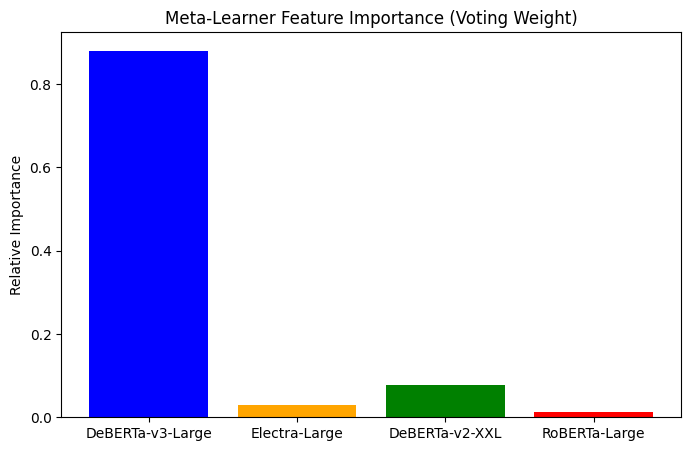

In [11]:
import matplotlib.pyplot as plt

# Load trained meta-learner
xgb_model = XGBClassifier()
xgb_model.load_model("saved_models/meta_learner_xgb.json")

# Get feature importance (8 features: 2 probabilities x 4 models)
importances = xgb_model.feature_importances_

# Combine Class 0 + Class 1 importance for each model
model_names = ["DeBERTa-v3-Large", "Electra-Large", "DeBERTa-v2-XXL", "RoBERTa-Large"]
combined_importances = [
    importances[0] + importances[1],  # DeBERTa-v3
    importances[2] + importances[3],  # Electra
    importances[4] + importances[5],  # DeBERTa-XXL
    importances[6] + importances[7]   # RoBERTa
]

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(model_names, combined_importances, color=['blue', 'orange', 'green', 'red'])
plt.title("Meta-Learner Feature Importance (Voting Weight)")
plt.ylabel("Relative Importance")
plt.show()

## 12. Generate Predictions

Run the ensemble on test data to generate predictions for submission.

In [20]:
group_number = "2"
ensemble = NLIBlendingEnsemble(model_configs=base_models)

# uncomment to run on val/ dev set
# ensemble.predict(test_csv_path='data/dev.csv', output_filename=f"nli_dev.csv")

ensemble.predict(test_csv_path='data/test.csv', output_filename=f"Group_" + group_number +"_C.csv")


=== Phase 3: Ensemble Inference ===
Extracting test features from microsoft/deberta-v3-large...


C:\Users\Julius\git\NLU\.venv\Lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting test features from google/electra-large-discriminator...


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-large-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting test features from microsoft/deberta-v2-xxlarge...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v2-xxlarge and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 2,362,370 || all params: 1,569,275,908 || trainable%: 0.1505
Extracting test features from roberta-large...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Feeding combined features to Meta-Learner...
Submission file saved to Group_2_C.csv


## 13. Token Length Analysis

Analyze the true token lengths in the dataset to choose an optimal `max_length` parameter. Using the 95th percentile balances efficiency (shorter sequences) with coverage (capturing most examples without truncation).

In [13]:
def analyze_true_token_lengths(dataframe, tokenizer_name):
    """
    Compute token length statistics for premise-hypothesis pairs.
    Helps choose optimal max_length for the model.
    """
    print(f"Loading tokenizer: {tokenizer_name}")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    df = dataframe.dropna(subset=['premise', 'hypothesis']).reset_index(drop=True)
    token_lengths = []

    print(f"Analyzing {len(df)} pairs...")
    for idx in tqdm(range(len(df))):
        premise = str(df.loc[idx, 'premise'])
        hypothesis = str(df.loc[idx, 'hypothesis'])

        # Tokenize WITHOUT truncation/padding to get true length
        encoding = tokenizer(
            premise,
            hypothesis,
            add_special_tokens=True,
            truncation=False,
            padding=False,
            return_tensors='pt'
        )

        actual_length = encoding['input_ids'].shape[1]
        token_lengths.append(actual_length)

    # Compute statistics
    lengths_array = np.array(token_lengths)
    max_len = lengths_array.max()
    mean_len = lengths_array.mean()
    p95 = np.percentile(lengths_array, 95)
    p99 = np.percentile(lengths_array, 99)

    print("\n--- TOKEN LENGTH STATISTICS ---")
    print(f"Maximum length:        {max_len} tokens")
    print(f"Mean length:           {mean_len:.1f} tokens")
    print(f"95th percentile:       {p95:.0f} tokens")
    print(f"99th percentile:       {p99:.0f} tokens")

    return int(p95), int(max_len)


# Run analysis
train_df = pd.read_csv("Data/train.csv")
recommended_max, absolute_max = analyze_true_token_lengths(train_df, 'microsoft/deberta-v3-large')

Loading tokenizer: microsoft/deberta-v3-large


C:\Users\Julius\git\NLU\.venv\Lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Analyzing 24432 pairs...


100%|██████████| 24432/24432 [00:02<00:00, 9244.55it/s]


--- TOKEN LENGTH STATISTICS ---
Maximum length:        320 tokens
Mean length:           38.2 tokens
95th percentile:       67 tokens
99th percentile:       91 tokens
